<a href="https://colab.research.google.com/github/orcasandpandas/Data-Science-Cohort-20/blob/main/Project_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.



The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.



There are three files in this data set:
- [the feature set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle ), i.e. images of dogs and cats ( mostly )
- [the target set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle ), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg )





This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.


The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.




https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg


## Data Loading

In [1]:
import tensorflow.keras as keras
import tensorflow as tf
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [4]:
image_array = image_array / 255.0
image_array

array([[[[0.37254902],
         [0.36862745],
         [0.38431373],
         ...,
         [0.66666667],
         [0.6745098 ],
         [0.67058824]],

        [[0.36078431],
         [0.35686275],
         [0.37254902],
         ...,
         [0.66666667],
         [0.6745098 ],
         [0.67058824]],

        [[0.34901961],
         [0.35686275],
         [0.36078431],
         ...,
         [0.64705882],
         [0.6627451 ],
         [0.6627451 ]],

        ...,

        [[0.32941176],
         [0.29803922],
         [0.28627451],
         ...,
         [0.52941176],
         [0.64313725],
         [0.60392157]],

        [[0.32156863],
         [0.30980392],
         [0.27843137],
         ...,
         [0.55686275],
         [0.5254902 ],
         [0.6       ]],

        [[0.31372549],
         [0.33333333],
         [0.33333333],
         ...,
         [0.59215686],
         [0.57254902],
         [0.54117647]]],


       [[[0.67058824],
         [0.60392157],
         [0.54

In [5]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [6]:
target = pd.read_pickle( target_url )
type(target)


list

## Exploratory Data Analysis

In [7]:
image_array.shape

(24946, 100, 100, 1)

In [8]:
target = np.array(target)
target.shape

(24946,)

0


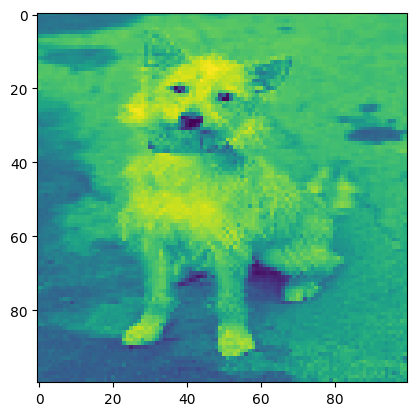

1


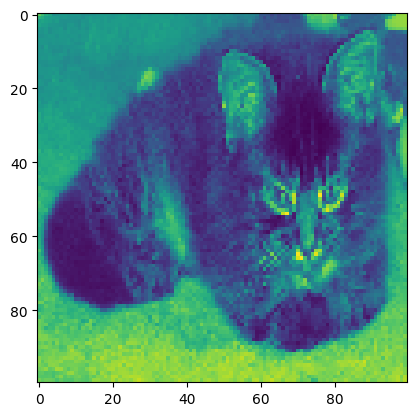

1


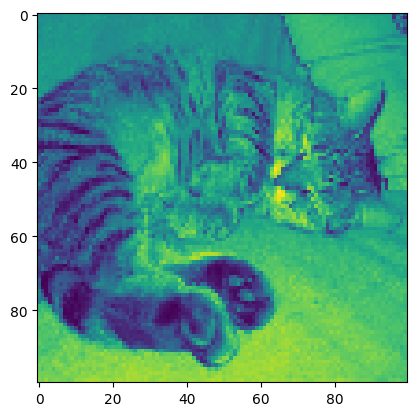

0


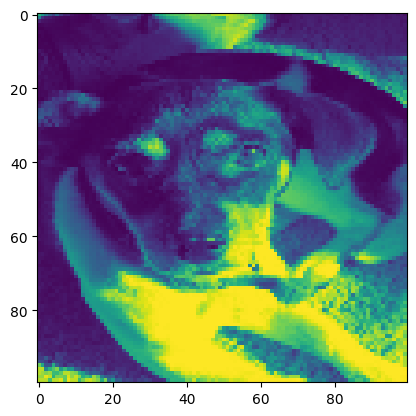

0


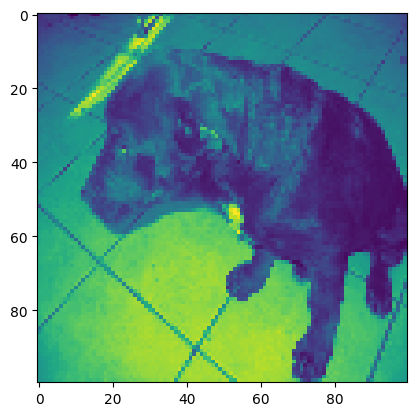

0


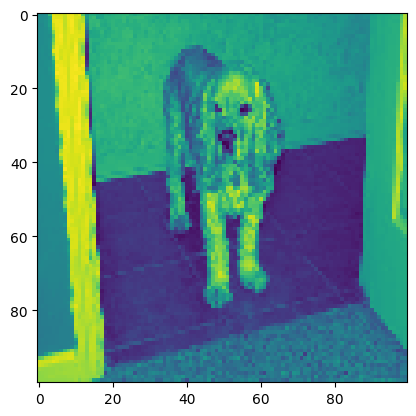

In [9]:
for i in range(6):

  print(target[i])
  plt.imshow(image_array[i])
  plt.show()

## Data Processing

In [13]:
X_train, X_test, y_train, y_test = train_test_split( image_array, target, test_size = 0.2 )


In [11]:
model = Sequential()


In [15]:
# Define input layer
model.add(
  Input(
    shape=X_train.shape[1:],
    name="model_input",
  ),
)


In [16]:
# Define first hidden layer
model.add(
  Conv2D(
    name = "Conv1",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


In [17]:
# Define second hidden layer
model.add(
  Conv2D(
    name = "Conv2",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


In [18]:
# Define third hidden layer
model.add(
  Conv2D(
    name = "Conv3",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


In [19]:
# Flatten data to be used in output layer
model.add(
    Flatten()
)

# Define output layer
model.add(
  Dense(
    name = "output",
    units = 1,
    activation = 'sigmoid',
  )
)


In [20]:
# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'binary_crossentropy',
  metrics = ['accuracy'],
)


In [21]:
# Fit model
model.fit(
    X_train,
    y_train,
    epochs=8,
    validation_data=(X_test, y_test))

Epoch 1/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.6648 - loss: 0.6013 - val_accuracy: 0.7289 - val_loss: 0.5292
Epoch 2/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7781 - loss: 0.4751 - val_accuracy: 0.7914 - val_loss: 0.4495
Epoch 3/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8100 - loss: 0.4151 - val_accuracy: 0.8218 - val_loss: 0.3955
Epoch 4/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8375 - loss: 0.3648 - val_accuracy: 0.8343 - val_loss: 0.3733
Epoch 5/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8599 - loss: 0.3239 - val_accuracy: 0.8309 - val_loss: 0.3793
Epoch 6/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8823 - loss: 0.2793 - val_accuracy: 0.8409 - val_loss: 0.3638
Epoch 7/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9015 - loss: 0.2390 - val_accuracy: 0.8511 - val_loss: 0.3507
Epoch 8/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9170 - loss: 0.2015 - val_accuracy: 0

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │        12,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,421 (1.21 MB)

 Trainable params: 105,473 (412.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 210,948 (824.02 KB)

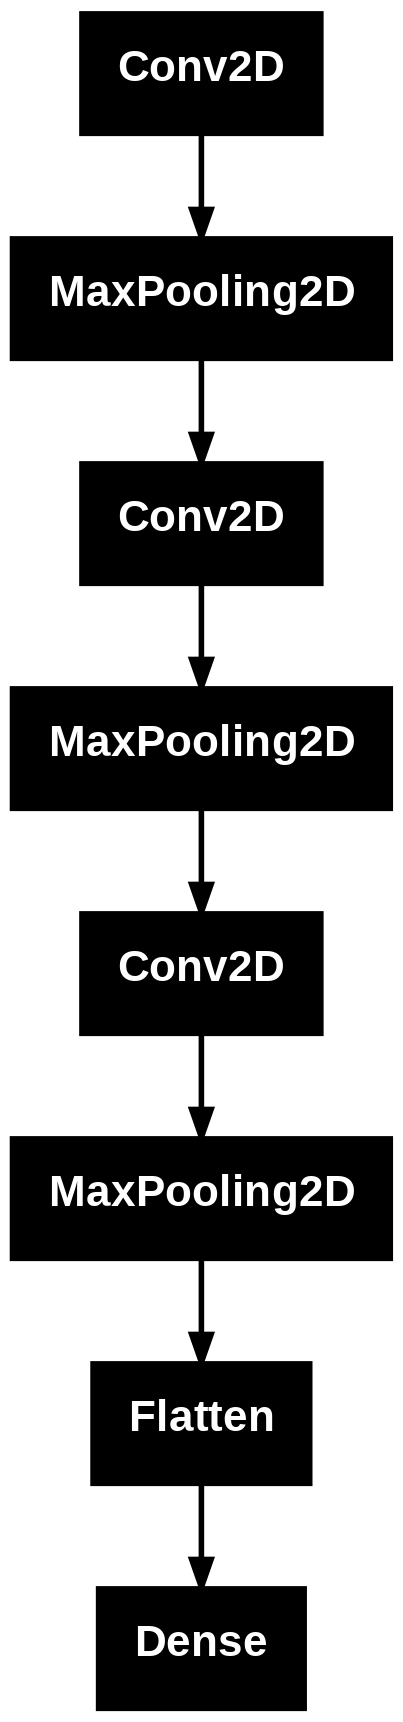

In [23]:
plot_model(model)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


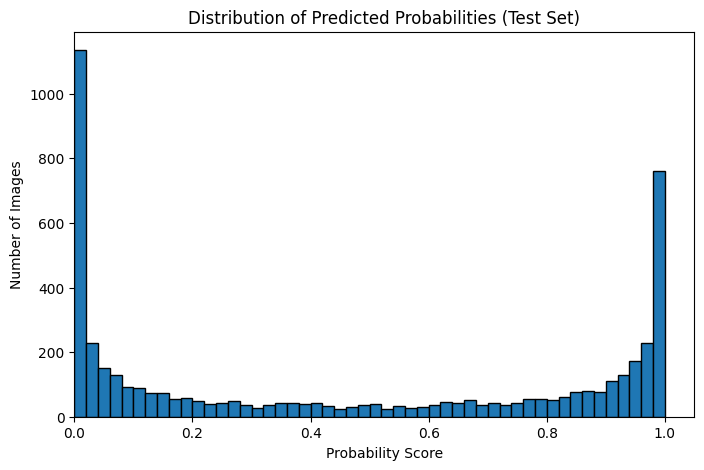

In [45]:
y_probs = model.predict(X_test)

# 2. Flatten the array so it is a simple 1D list of numbers
y_probs_flat = y_probs.flatten()

# 3. Plot the histogram
plt.figure(figsize=(8, 5))
plt.hist(y_probs_flat, bins=50, edgecolor='black')

plt.title("Distribution of Predicted Probabilities (Test Set)")
plt.xlabel("Probability Score")
plt.ylabel("Number of Images")
plt.xlim(left=0)
plt.show()

In [24]:
val_loss, val_acc = model.evaluate(X_test, y_test)
print(val_loss)
print(val_acc)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8471 - loss: 0.3654
0.36538511514663696
0.8470941781997681


(100, 100)

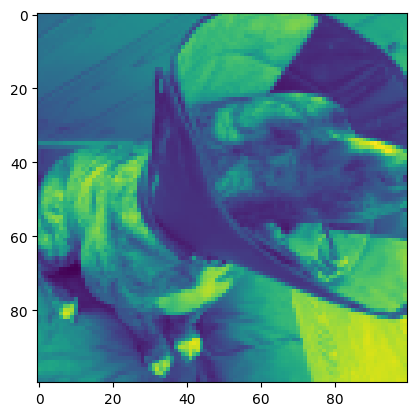

In [26]:
from skimage import io
from skimage.transform import resize

dog_pic = io.imread("https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg", as_gray=True)


dog_pic = resize(dog_pic, (100, 100))
dog_pic = dog_pic.astype("float32")
plt.imshow(dog_pic)


dog_pic.shape

In [27]:
dog_pic = dog_pic[None, :, :, None]
dog_pic.shape



(1, 100, 100, 1)

In [28]:
prediction = model.predict(dog_pic)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step


In [29]:
prediction

array([[0.22494885]], dtype=float32)

In [30]:
def predictor(url):
  pic = io.imread(url, as_gray=True)
  pic = resize(pic, (100, 100))
  pic = pic.astype("float32")
  plt.imshow(pic)

  pic = pic[None, :, :, None]
  prediction = model.predict(pic)
  return prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


array([[0.99797994]], dtype=float32)

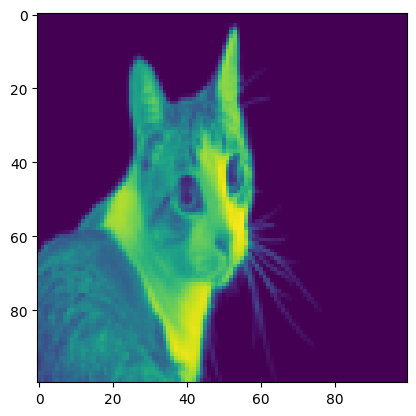

In [36]:
predictor("https://i.natgeofe.com/n/548467d8-c5f1-4551-9f58-6817a8d2c45e/NationalGeographic_2572187_16x9.jpg?w=1200")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[0.02592563]], dtype=float32)

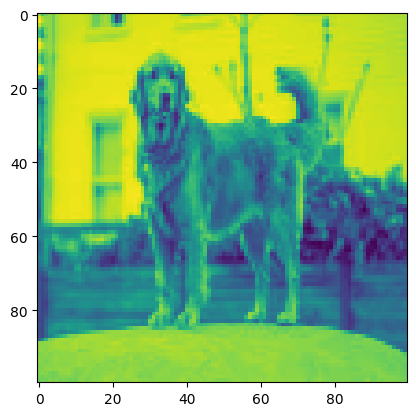

In [32]:
predictor("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRInKFKLo7HSnAQ5DGzi7s0OwOSoQ7qxFHyrA&s")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


array([[0.9895772]], dtype=float32)

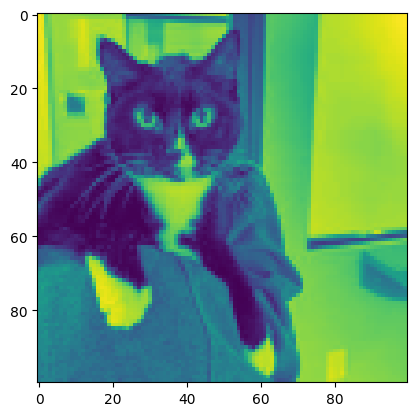

In [39]:
predictor("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ3Tog1i_Z22gc_DNAfSt78ggHO3veuGrqJTA&s")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


array([[0.72018903]], dtype=float32)

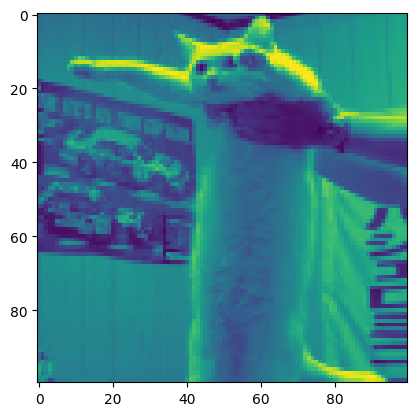

In [40]:
predictor("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ2noXCG82l_cLZrt9oAQt4aMquZiIhOVvITA&s")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[0.01593575]], dtype=float32)

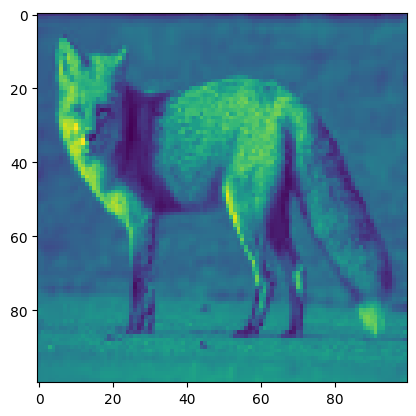

In [42]:
predictor("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS5UUpSI7aylY22oONceYePdTWe0ojvjXmx-A&s")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


array([[0.6281147]], dtype=float32)

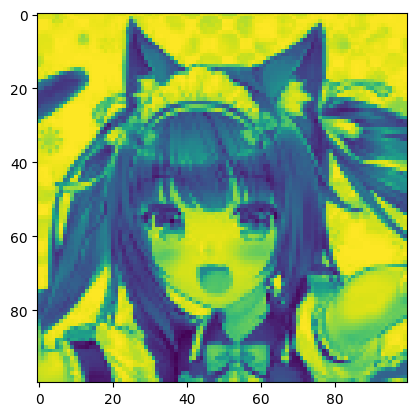

In [43]:
predictor("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT-YfPbML_UP6kTOUV0_LBSGj0u9r4AaXVJEA&s")